In [66]:
# CELL 1: Imports & Basic Setup

import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("="*60)
print("🔬 MBTI PLAYLIST CLASSIFIER - Transfer Learning from Autoencoder")
print("="*60)
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

🔬 MBTI PLAYLIST CLASSIFIER - Transfer Learning from Autoencoder
Using device: cpu
PyTorch version: 2.10.0+cpu


In [67]:
# CELL 2: Mount Google Drive & Define Paths

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/mbti-tune")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw"
MBTI_PLAYLIST_DIR = RAW_DIR / "mbti_playlists"
RAW_PLAYLIST_DIR = RAW_DIR / "raw_playlists"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"MBTI_PLAYLIST_DIR: {MBTI_PLAYLIST_DIR}")
print(f"RAW_PLAYLIST_DIR: {RAW_PLAYLIST_DIR}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/mbti-tune
MBTI_PLAYLIST_DIR: /content/drive/MyDrive/mbti-tune/data/raw/mbti_playlists
RAW_PLAYLIST_DIR: /content/drive/MyDrive/mbti-tune/data/raw/raw_playlists
PROCESSED_DIR: /content/drive/MyDrive/mbti-tune/data/processed


In [68]:
# CELL 3: Define Standard Audio Features (Matches Autoencoder)

# Standard audio features (9 features) - MUST match autoencoder
AUDIO_FEATURES = [
    'danceability', 'energy', 'valence', 'acousticness',
    'instrumentalness', 'speechiness', 'loudness', 'tempo', 'liveness'
]

# Column mapping from raw_playlists to standard names
RAW_COLUMN_MAPPING = {
    'Dance': 'danceability',
    'Energy': 'energy',
    'Valence': 'valence',
    'Acoustic': 'acousticness',
    'Instrumental': 'instrumentalness',
    'Speech': 'speechiness',
    'Loud (Db)': 'loudness',
    'BPM': 'tempo',
    'Live': 'liveness',
    'Key': 'key',
    'Popularity': 'popularity'
}

print(f"Standard audio features: {len(AUDIO_FEATURES)}")
print(f"Features: {AUDIO_FEATURES}")

Standard audio features: 9
Features: ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'speechiness', 'loudness', 'tempo', 'liveness']


In [69]:
# CELL 4: Extract Raw Songs from Playlists (For Transfer Learning)

print("="*60)
print("🎵 Extracting Raw Songs from Playlists")
print("="*60)

all_raw_songs = []
song_metadata = []  # Track which playlist each song belongs to

total_songs = 0
playlist_count = 0

for mbti_folder in RAW_PLAYLIST_DIR.iterdir():
    if not mbti_folder.is_dir():
        continue

    mbti_type = mbti_folder.name
    print(f"\n📁 Processing {mbti_type}...")

    for csv_file in mbti_folder.glob("*.csv"):
        playlist_count += 1
        playlist_name = csv_file.stem

        try:
            df = pd.read_csv(csv_file)
            df = df.rename(columns=RAW_COLUMN_MAPPING)

            for idx, row in df.iterrows():
                song_features = {}
                for feat in AUDIO_FEATURES:
                    value = row.get(feat, 0)
                    # Convert percentage values (0-100) to 0-1 scale
                    if isinstance(value, (int, float)) and feat not in ['loudness', 'tempo']:
                        if value > 1 and value <= 100:
                            value = value / 100.0
                    song_features[feat] = float(value) if not pd.isna(value) else 0.0

                all_raw_songs.append(song_features)
                song_metadata.append({
                    'mbti': mbti_type,
                    'playlist_name': playlist_name
                })
                total_songs += 1

        except Exception as e:
            continue

# Create DataFrame
raw_song_df = pd.DataFrame(all_raw_songs)
metadata_df = pd.DataFrame(song_metadata)

print(f"\n✅ Extracted {total_songs:,} raw songs from {playlist_count} playlists")
print(f"✅ Audio features shape: {raw_song_df.shape}")
print(f"\n📊 Sample raw song features:")
print(raw_song_df.head())

🎵 Extracting Raw Songs from Playlists

📁 Processing ESFJ...

📁 Processing ENFP...

📁 Processing ENFJ...

📁 Processing ENTJ...

📁 Processing ENTP...

📁 Processing ESTP...

📁 Processing ESFP...

📁 Processing ESTJ...

📁 Processing INFJ...

📁 Processing INFP...

📁 Processing ISFJ...

📁 Processing INTP...

📁 Processing INTJ...

📁 Processing ISFP...

📁 Processing ISTJ...

📁 Processing ISTP...

✅ Extracted 54,343 raw songs from 326 playlists
✅ Audio features shape: (54343, 9)

📊 Sample raw song features:
   danceability  energy  valence  acousticness  instrumentalness  speechiness  \
0          0.70    0.57     0.70          0.20               0.0          0.1   
1          0.56    0.43     0.14          0.77               0.0          0.0   
2          0.40    0.44     0.34          0.77               0.0          0.1   
3          0.73    0.71     0.56          0.22               0.0          0.0   
4          0.66    0.86     0.75          0.05               0.0          0.0   

   loudnes

In [70]:
# CELL 5: Autoencoder Architecture (Matches Notebook 1)

print("="*60)
print("🏗️ Autoencoder Architecture")
print("="*60)

class SongAutoencoder(nn.Module):
    def __init__(self, input_dim=9, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

    def encode(self, x):
        return self.encoder(x)

print("Autoencoder architecture defined")
print("  Input: 9 audio features")
print("  Latent: 32 dimensions")

🏗️ Autoencoder Architecture
Autoencoder architecture defined
  Input: 9 audio features
  Latent: 32 dimensions


In [71]:
# CELL 6: Load Pretrained Autoencoder from Notebook 1

print("="*60)
print("📥 Loading Pretrained Autoencoder")
print("="*60)

autoencoder_path = PROCESSED_DIR / "autoencoder_model.pth"
scaler_path = PROCESSED_DIR / "song_scaler.pkl"

has_pretrained = False

if autoencoder_path.exists():
    try:
        checkpoint = torch.load(autoencoder_path, map_location='cpu', weights_only=False)

        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint

        autoencoder = SongAutoencoder()
        autoencoder.load_state_dict(state_dict, strict=False)
        encoder = autoencoder.encoder
        encoder.eval()
        has_pretrained = True

        print(f"✅ Loaded pretrained autoencoder from {autoencoder_path}")
        print(f"   Encoder output dimension: 32")

        # Load the scaler
        if scaler_path.exists():
            scaler_songs = joblib.load(scaler_path)
            print(f"✅ Loaded song scaler from {scaler_path}")
        else:
            print(f"⚠️ Scaler not found. Will create new scaler.")
            scaler_songs = None

    except Exception as e:
        print(f"⚠️ Could not load autoencoder: {e}")
        has_pretrained = False
else:
    print(f"⚠️ Autoencoder not found at {autoencoder_path}")
    print("   Run Notebook 1 first, or continue without transfer learning")

# Move to device
if has_pretrained:
    encoder = encoder.to(device)

📥 Loading Pretrained Autoencoder
✅ Loaded pretrained autoencoder from /content/drive/MyDrive/mbti-tune/data/processed/autoencoder_model.pth
   Encoder output dimension: 32
✅ Loaded song scaler from /content/drive/MyDrive/mbti-tune/data/processed/song_scaler.pkl


In [72]:
# CELL 7: Generate Song Embeddings Using Pretrained Encoder

print("="*60)
print("🎯 Generating Song Embeddings")
print("="*60)

if has_pretrained:
    # Prepare raw song features
    X_raw_songs = raw_song_df[AUDIO_FEATURES].values.astype(np.float32)
    X_raw_songs = np.nan_to_num(X_raw_songs)

    # Scale using pretrained scaler or fit new one
    if scaler_songs is not None:
        X_scaled_songs = scaler_songs.transform(X_raw_songs)
        print(f"✅ Used pretrained scaler")
    else:
        scaler_songs = StandardScaler()
        X_scaled_songs = scaler_songs.fit_transform(X_raw_songs)
        joblib.dump(scaler_songs, PROCESSED_DIR / "playlist_song_scaler.pkl")
        print(f"✅ Created new scaler for playlist songs")

    print(f"   Scaled features shape: {X_scaled_songs.shape}")

    # Generate embeddings in batches
    song_embeddings = []
    batch_size = 2048

    with torch.no_grad():
        for i in range(0, len(X_scaled_songs), batch_size):
            batch = torch.tensor(X_scaled_songs[i:i+batch_size], dtype=torch.float32).to(device)
            embeddings = encoder(batch)
            song_embeddings.append(embeddings.cpu().numpy())

    song_embeddings = np.concatenate(song_embeddings, axis=0)
    print(f"\n✅ Generated {song_embeddings.shape[0]:,} song embeddings")
    print(f"   Embedding dimension: {song_embeddings.shape[1]}")

    # Add embeddings to dataframe
    for i in range(song_embeddings.shape[1]):
        raw_song_df[f'embedding_{i}'] = song_embeddings[:, i]

    # Add metadata
    raw_song_df['playlist_name'] = metadata_df['playlist_name']
    raw_song_df['mbti'] = metadata_df['mbti']

    # Save
    raw_song_df.to_csv(PROCESSED_DIR / "raw_songs_with_embeddings.csv", index=False)
    print(f"✅ Saved songs with embeddings to {PROCESSED_DIR / 'raw_songs_with_embeddings.csv'}")

else:
    print("⚠️ Cannot generate embeddings - no pretrained encoder available")

🎯 Generating Song Embeddings
✅ Used pretrained scaler
   Scaled features shape: (54343, 9)

✅ Generated 54,343 song embeddings
   Embedding dimension: 32
✅ Saved songs with embeddings to /content/drive/MyDrive/mbti-tune/data/processed/raw_songs_with_embeddings.csv


In [73]:
# CELL 8: Aggregate Song Embeddings to Playlist Level

print("="*60)
print("📊 Aggregating Song Embeddings to Playlist Level")
print("="*60)

if has_pretrained:
    embedding_cols = [f'embedding_{i}' for i in range(song_embeddings.shape[1])]
    playlist_aggregated = []

    for playlist_name in raw_song_df['playlist_name'].unique():
        playlist_songs = raw_song_df[raw_song_df['playlist_name'] == playlist_name]
        mbti_type = playlist_songs['mbti'].iloc[0]

        # Get embedding matrix for this playlist
        embedding_matrix = playlist_songs[embedding_cols].values

        # Aggregate: mean, std, min, max (4 × 32 = 128 features)
        agg_embedding = np.concatenate([
            np.mean(embedding_matrix, axis=0),   # 32 features
            np.std(embedding_matrix, axis=0),    # 32 features
            np.min(embedding_matrix, axis=0),    # 32 features
            np.max(embedding_matrix, axis=0)     # 32 features
        ])

        playlist_aggregated.append({
            'playlist_name': playlist_name,
            'mbti': mbti_type,
            'embedding_features': agg_embedding
        })

    # Create DataFrame
    embedding_features_df = pd.DataFrame(playlist_aggregated)

    # Expand embedding features into columns
    embedding_expanded = pd.DataFrame(
        embedding_features_df['embedding_features'].tolist(),
        columns=[f'transfer_emb_{i}' for i in range(128)]
    )

    embedding_features_df = pd.concat([
        embedding_features_df[['playlist_name', 'mbti']],
        embedding_expanded
    ], axis=1)

    print(f"✅ Created {len(embedding_features_df)} playlist-level embeddings")
    print(f"   Features: 128 aggregated embedding features")

    # Save
    embedding_features_df.to_csv(PROCESSED_DIR / "playlist_embedding_features.csv", index=False)
    print(f"✅ Saved to {PROCESSED_DIR / 'playlist_embedding_features.csv'}")

else:
    print("⚠️ Cannot aggregate embeddings - no pretrained encoder available")

📊 Aggregating Song Embeddings to Playlist Level
✅ Created 324 playlist-level embeddings
   Features: 128 aggregated embedding features
✅ Saved to /content/drive/MyDrive/mbti-tune/data/processed/playlist_embedding_features.csv


In [74]:
# CELL 9: Load MBTI Playlist Stats (43 Features)

print("="*60)
print("📊 Loading MBTI Playlist Stats")
print("="*60)

# Define the 43 features we want from mbti_playlists
AUDIO_FEATURES = ['danceability', 'energy', 'valence', 'acousticness',
                   'instrumentalness', 'speechiness', 'loudness', 'tempo', 'liveness']

# Build feature column list
STATS_FEATURES = []
for feat in AUDIO_FEATURES:
    STATS_FEATURES.append(f'{feat}_mean')
    STATS_FEATURES.append(f'{feat}_stdev')

# Key/Mode counts (24 features)
key_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
for name in key_names:
    STATS_FEATURES.append(f'{name}Major_count')
    STATS_FEATURES.append(f'{name}minor_count')

STATS_FEATURES.append('track_count')

print(f"Expected stats features: {len(STATS_FEATURES)}")

# Load all mbti_playlists
all_stats = []
for csv_file in MBTI_PLAYLIST_DIR.glob("*.csv"):
    df = pd.read_csv(csv_file)
    all_stats.append(df)

stats_df = pd.concat(all_stats, ignore_index=True)

# Ensure all feature columns exist
for col in STATS_FEATURES:
    if col not in stats_df.columns:
        stats_df[col] = 0.0
        print(f"  Added missing column: {col}")

# Keep only needed columns
stats_df = stats_df[['playlist_id', 'playlist_name', 'mbti'] + STATS_FEATURES]

print(f"\n✅ Loaded {len(stats_df)} playlists with {len(STATS_FEATURES)} features")
print(f"   MBTI types: {stats_df['mbti'].nunique()}")

📊 Loading MBTI Playlist Stats
Expected stats features: 43
  Added missing column: C#Major_count
  Added missing column: C#minor_count
  Added missing column: D#Major_count
  Added missing column: D#minor_count
  Added missing column: F#Major_count
  Added missing column: F#minor_count
  Added missing column: G#Major_count
  Added missing column: G#minor_count
  Added missing column: A#Major_count
  Added missing column: A#minor_count

✅ Loaded 4201 playlists with 43 features
   MBTI types: 16


In [76]:
# CELL 10: Merge Features
print("="*60)
print("🔗 Merging Features - Combine All Playlists")
print("="*60)

if has_pretrained and 'embedding_features_df' in dir():
    # Clean playlist names for matching
    stats_df['clean_name'] = stats_df['playlist_name'].str.replace('.csv', '').str.strip()
    embedding_features_df['clean_name'] = embedding_features_df['playlist_name'].str.strip()

    # Create a lookup dictionary for embedding features
    embedding_dict = {}
    for _, row in embedding_features_df.iterrows():
        playlist_name = row['clean_name']
        embedding_dict[playlist_name] = [row[f'transfer_emb_{i}'] for i in range(128)]

    # Add embedding features to stats_df (LEFT JOIN logic)
    embedding_cols = [f'transfer_emb_{i}' for i in range(128)]
    for col in embedding_cols:
        stats_df[col] = 0.0  # Initialize with zeros

    # Fill embeddings for matching playlists
    matched_count = 0
    for idx, row in stats_df.iterrows():
        playlist_name = row['clean_name']
        if playlist_name in embedding_dict:
            matched_count += 1
            for i, val in enumerate(embedding_dict[playlist_name]):
                stats_df.at[idx, f'transfer_emb_{i}'] = val

    # Define final feature columns
    feature_cols = STATS_FEATURES + embedding_cols
    final_df = stats_df[['playlist_id', 'playlist_name', 'mbti'] + feature_cols].copy()

    print(f"\n✅ Merged features: {len(final_df)} playlists")
    print(f"   Playlists WITH transfer embeddings: {matched_count}")
    print(f"   Playlists WITHOUT (using zeros): {len(final_df) - matched_count}")
    print(f"   Total features: {len(feature_cols)} (43 stats + 128 transfer)")

else:
    # Fallback: use only stats features
    print("⚠️ Transfer learning features not available. Using only stats features.")
    feature_cols = STATS_FEATURES
    final_df = stats_df[['playlist_id', 'playlist_name', 'mbti'] + feature_cols].copy()
    print(f"   Features: {len(feature_cols)} (stats only)")

🔗 Merging Features - Combine All Playlists

✅ Merged features: 4201 playlists
   Playlists WITH transfer embeddings: 678
   Playlists WITHOUT (using zeros): 3523
   Total features: 171 (43 stats + 128 transfer)


In [77]:
# CELL 11: Prepare Features and Labels

print("="*60)
print("📊 Preparing Features and Labels")
print("="*60)

# Extract features and labels
X_raw = final_df[feature_cols].values.astype(np.float32)
y_raw = final_df['mbti'].values

print(f"X shape: {X_raw.shape}")
print(f"y shape: {y_raw.shape}")

# Handle NaN/Inf
X_clean = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean).astype(np.float32)

print(f"\nX_scaled shape: {X_scaled.shape}")
print(f"X_scaled - min: {X_scaled.min():.3f}, max: {X_scaled.max():.3f}, mean: {X_scaled.mean():.3f}")

# Encode MBTI labels
unique_types = sorted(np.unique(y_raw))
type_to_idx = {t: i for i, t in enumerate(unique_types)}
idx_to_type = {i: t for t, i in type_to_idx.items()}
y = np.array([type_to_idx[t] for t in y_raw], dtype=np.int64)

print(f"\nMBTI classes: {len(unique_types)}")
print(f"Class distribution:")
for t in unique_types:
    count = np.sum(y == type_to_idx[t])
    print(f"  {t}: {count} playlists")

📊 Preparing Features and Labels
X shape: (4201, 171)
y shape: (4201,)

X_scaled shape: (4201, 171)
X_scaled - min: -15.339, max: 23.220, mean: 0.000

MBTI classes: 16
Class distribution:
  ENFJ: 302 playlists
  ENFP: 302 playlists
  ENTJ: 303 playlists
  ENTP: 303 playlists
  ESFJ: 115 playlists
  ESFP: 231 playlists
  ESTJ: 122 playlists
  ESTP: 306 playlists
  INFJ: 304 playlists
  INFP: 295 playlists
  INTJ: 307 playlists
  INTP: 299 playlists
  ISFJ: 221 playlists
  ISFP: 295 playlists
  ISTJ: 196 playlists
  ISTP: 300 playlists


In [78]:
# CELL 12: Train/Val/Test Split

print("="*60)
print("📊 Creating Train/Val/Test Splits")
print("="*60)

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)} ({len(X_train)/len(y)*100:.1f}%)")
print(f"Val size:   {len(X_val)} ({len(X_val)/len(y)*100:.1f}%)")
print(f"Test size:  {len(X_test)} ({len(X_test)/len(y)*100:.1f}%)")

# PyTorch Dataset
class PlaylistDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 16
train_loader = DataLoader(PlaylistDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(PlaylistDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(PlaylistDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print(f"\nBatch size: {batch_size}")

📊 Creating Train/Val/Test Splits
Train size: 2940 (70.0%)
Val size:   630 (15.0%)
Test size:  631 (15.0%)

Batch size: 16


In [79]:
# CELL 13: Define MBTI Classifier

print("="*60)
print("🏗️ Building MBTI Classifier")
print("="*60)

class MBTIClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=16, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(hidden_dim // 4, num_classes)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = MBTIClassifier(
    input_dim=input_dim,
    hidden_dim=64,
    num_classes=len(unique_types),
    dropout_rate=0.3
).to(device)

print(f"Input dimension: {input_dim}")
print(f"Architecture: {input_dim} → 64 → 32 → 16 → {len(unique_types)}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Transfer learning features: {'✅ Enabled' if has_pretrained else '❌ Disabled'}")

🏗️ Building MBTI Classifier
Input dimension: 171
Architecture: 171 → 64 → 32 → 16 → 16
Total parameters: 14,112
Transfer learning features: ✅ Enabled


In [80]:
# CELL 14: Training Setup

print("="*60)
print("⚙️ Training Setup")
print("="*60)

# Class weights for imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Class weights range: {class_weights.min():.3f} - {class_weights.max():.3f}")

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

num_epochs = 200
print(f"\nEpochs: {num_epochs}")
print(f"Learning rate: 1e-3")
print(f"Weight decay: 1e-4")

⚙️ Training Setup
Class weights range: 0.855 - 2.269

Epochs: 200
Learning rate: 1e-3
Weight decay: 1e-4


In [81]:
# CELL 15: Train Model

print("="*60)
print("🚀 Training Model")
print("="*60)

best_val_loss = float('inf')
best_state = None
patience_counter = 0
train_losses = []
val_losses = []

for epoch in range(1, num_epochs + 1):
    # Training
    model.train()
    train_loss_epoch = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss_epoch.append(loss.item())

    avg_train_loss = np.mean(train_loss_epoch)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss_epoch = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss_epoch.append(loss.item())

    avg_val_loss = np.mean(val_loss_epoch)
    val_losses.append(avg_val_loss)

    # Learning rate scheduling
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    # Progress
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f} | lr={old_lr:.2e}")
        if new_lr != old_lr:
            print(f"  📉 Learning rate reduced to {new_lr:.2e}")

    # Early stopping
    if patience_counter >= 40:
        print(f"\nEarly stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)
print(f"\n✅ Training complete! Best validation loss: {best_val_loss:.4f}")

🚀 Training Model
Epoch 001 | train_loss=2.7893 | val_loss=2.6917 | lr=1.00e-03
Epoch 020 | train_loss=2.4214 | val_loss=2.2657 | lr=1.00e-03
Epoch 040 | train_loss=2.3114 | val_loss=2.2278 | lr=1.00e-03
Epoch 060 | train_loss=2.3024 | val_loss=2.1850 | lr=1.00e-03
Epoch 080 | train_loss=2.2503 | val_loss=2.1493 | lr=1.00e-03
Epoch 100 | train_loss=2.2172 | val_loss=2.1607 | lr=1.00e-03
Epoch 120 | train_loss=2.2037 | val_loss=2.1213 | lr=1.00e-03
Epoch 140 | train_loss=2.1693 | val_loss=2.1056 | lr=5.00e-04
Epoch 160 | train_loss=2.1338 | val_loss=2.1175 | lr=2.50e-04
Epoch 180 | train_loss=2.1152 | val_loss=2.1136 | lr=1.25e-04
Epoch 200 | train_loss=2.1411 | val_loss=2.1046 | lr=1.25e-04

✅ Training complete! Best validation loss: 2.0944


📊 Test Set Evaluation

✅ Test Accuracy: 0.3677 (36.77%)
Random baseline: 6.2%

📋 Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.31      0.24      0.27        46
        ENFP       0.60      0.33      0.42        46
        ENTJ       0.45      0.54      0.49        46
        ENTP       0.60      0.52      0.56        46
        ESFJ       0.17      0.24      0.20        17
        ESFP       0.31      0.53      0.39        34
        ESTJ       0.20      0.39      0.26        18
        ESTP       0.40      0.41      0.40        46
        INFJ       0.49      0.46      0.47        46
        INFP       0.25      0.32      0.28        44
        INTJ       0.24      0.17      0.20        46
        INTP       0.34      0.44      0.38        45
        ISFJ       0.29      0.36      0.32        33
        ISFP       0.56      0.34      0.42        44
        ISTJ       0.40      0.14      0.21        29
        ISTP       0.38      0.

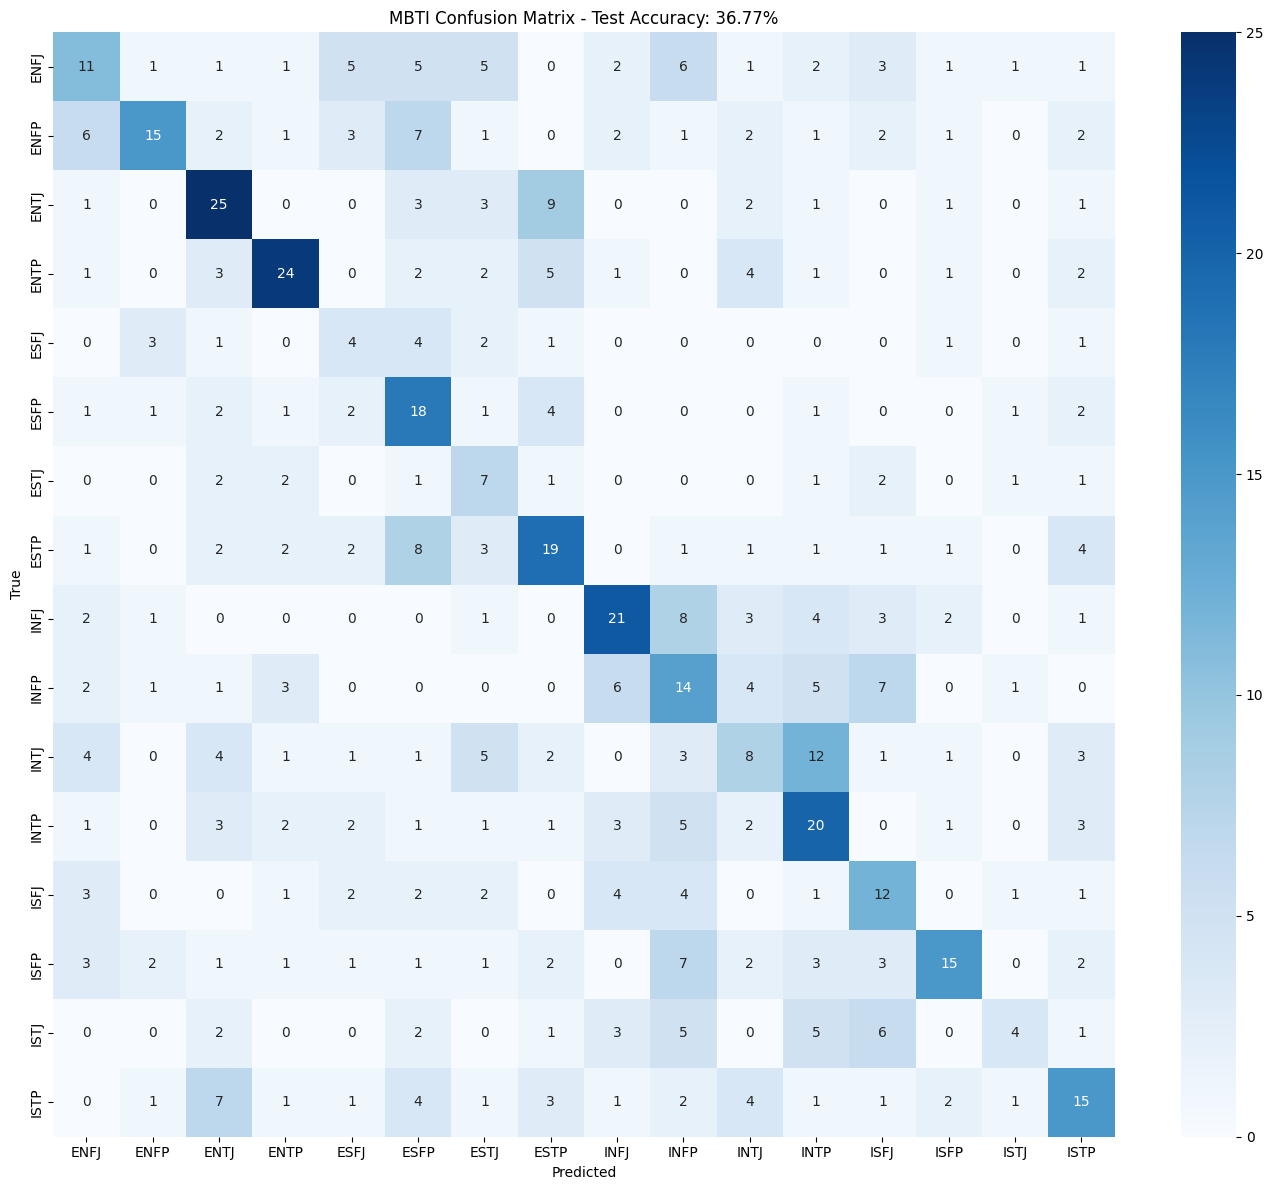

In [82]:
# CELL 16: Evaluate on Test Set

print("="*60)
print("📊 Test Set Evaluation")
print("="*60)

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"\n✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Random baseline: {1/len(unique_types)*100:.1f}%")

# Classification report
print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=unique_types))

# Confusion Matrix
plt.figure(figsize=(14, 12))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_types, yticklabels=unique_types)
plt.title(f'MBTI Confusion Matrix - Test Accuracy: {test_acc:.2%}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [83]:
# CELL 17: Axis Accuracy Analysis

print("="*60)
print("📊 Axis Accuracy Analysis")
print("="*60)

def get_letter(mbti_str, position):
    return mbti_str[position] if mbti_str and len(mbti_str) > position else '?'

axis_info = [('E/I', 0, 'E', 'I'), ('S/N', 1, 'S', 'N'),
             ('T/F', 2, 'T', 'F'), ('J/P', 3, 'J', 'P')]

print(f"\n{'Axis':<6} {'Letter':<8} {'True %':<10} {'Predicted %':<12} {'Accuracy':<10}")
print(f"{'-'*55}")

for axis_name, pos, l1, l2 in axis_info:
    correct = sum(1 for t, p in zip(all_labels, all_preds)
                  if get_letter(idx_to_type[t], pos) == get_letter(idx_to_type[p], pos))
    acc = correct / len(all_labels) * 100

    true_l1 = sum(1 for t in all_labels if get_letter(idx_to_type[t], pos) == l1) / len(all_labels) * 100
    pred_l1 = sum(1 for p in all_preds if get_letter(idx_to_type[p], pos) == l1) / len(all_preds) * 100

    print(f"{axis_name:<6} {l1:<8} {true_l1:>5.1f}%       {pred_l1:>5.1f}%         {acc:>5.1f}%")
    print(f"{axis_name:<6} {l2:<8} {100-true_l1:>5.1f}%       {100-pred_l1:>5.1f}%         {'':>5}")

📊 Axis Accuracy Analysis

Axis   Letter   True %     Predicted %  Accuracy  
-------------------------------------------------------
E/I    E         47.4%        51.0%          76.7%
E/I    I         52.6%        49.0%              
S/N    S         42.2%        44.8%          69.7%
S/N    N         57.8%        55.2%              
T/F    T         50.9%        50.9%          75.0%
T/F    F         49.1%        49.1%              
J/P    J         44.5%        43.9%          65.8%
J/P    P         55.5%        56.1%              


In [84]:
# CELL 18: Save Model for Streamlit

print("="*60)
print("💾 Saving Model for Streamlit")
print("="*60)

# Save scaler
joblib.dump(scaler, PROCESSED_DIR / "mbti_scaler.pkl")
print(f"✅ Saved scaler to {PROCESSED_DIR / 'mbti_scaler.pkl'}")

# Save feature list
with open(PROCESSED_DIR / "mbti_features.json", "w") as f:
    json.dump(feature_cols, f)
print(f"✅ Saved feature list ({len(feature_cols)} features)")

# Save model checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'type_to_idx': type_to_idx,
    'idx_to_type': idx_to_type,
    'features': feature_cols,
    'input_dim': input_dim,
    'num_classes': len(unique_types),
    'test_accuracy': test_acc,
    'best_val_loss': best_val_loss,
    'transfer_learning_used': has_pretrained,
    'features_count': len(feature_cols)
}

torch.save(checkpoint, PROCESSED_DIR / "mbti_classifier.pth")
print(f"✅ Saved model to {PROCESSED_DIR / 'mbti_classifier.pth'}")

# Simplified version
simplified = {
    'model_state_dict': model.state_dict(),
    'idx_to_type': idx_to_type,
    'features': feature_cols,
}
torch.save(simplified, PROCESSED_DIR / "mbti_model_simplified.pth")
print(f"✅ Saved simplified model")

print("\n✅ All files saved! Ready for Streamlit deployment.")

💾 Saving Model for Streamlit
✅ Saved scaler to /content/drive/MyDrive/mbti-tune/data/processed/mbti_scaler.pkl
✅ Saved feature list (171 features)
✅ Saved model to /content/drive/MyDrive/mbti-tune/data/processed/mbti_classifier.pth
✅ Saved simplified model

✅ All files saved! Ready for Streamlit deployment.


📈 Training History


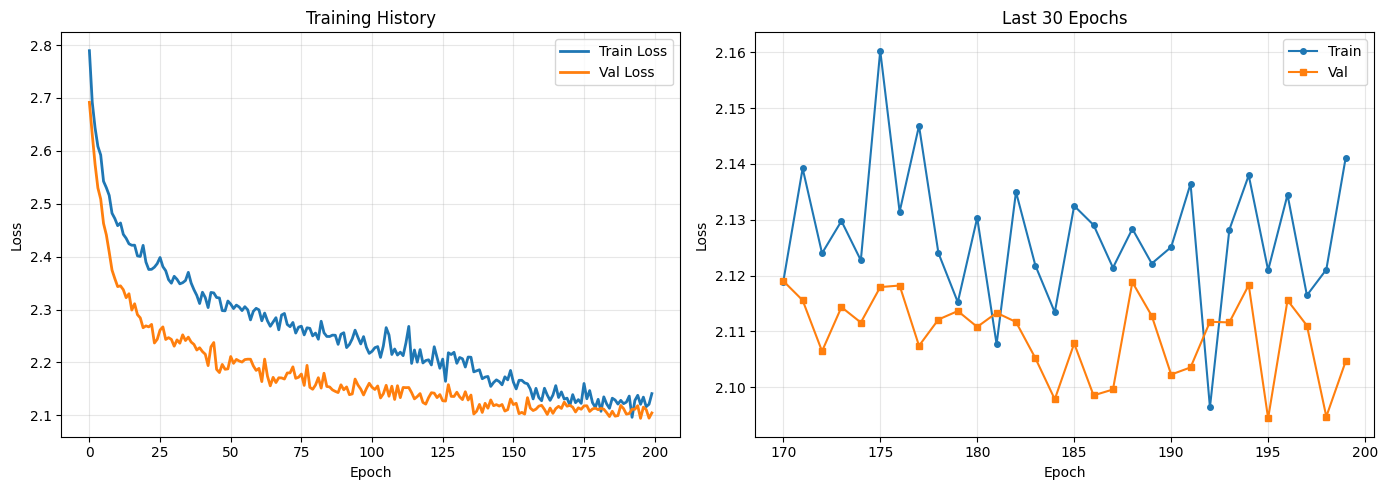

Final train loss: 2.1411
Final val loss: 2.1046
Best val loss: 2.0944


In [85]:
# CELL 19: Training History Visualization

print("="*60)
print("📈 Training History")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full curve
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Last 30 epochs
start = max(0, len(train_losses) - 30)
axes[1].plot(range(start, len(train_losses)), train_losses[start:], label='Train', marker='o', markersize=4)
axes[1].plot(range(start, len(val_losses)), val_losses[start:], label='Val', marker='s', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Last 30 Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")
print(f"Best val loss: {best_val_loss:.4f}")

In [86]:
# CELL 20: Final Summary

print("="*60)
print("📋 FINAL SUMMARY")
print("="*60)

print(f"""
📊 Dataset Statistics:
   Total playlists: {len(final_df)}
   Features used: {len(feature_cols)}
   - Stats features: {len(STATS_FEATURES)}
   - Transfer learning features: {128 if has_pretrained else 0}
   MBTI classes: {len(unique_types)}
   Train/Val/Test: {len(X_train)} / {len(X_val)} / {len(X_test)}

🎯 Model Performance:
   Test Accuracy: {test_acc:.2%}
   Random Baseline: {1/len(unique_types):.1%}
   Transfer Learning: {'✅ Enabled' if has_pretrained else '❌ Disabled'}

📁 Files Saved (for Streamlit):
   ✅ mbti_classifier.pth
   ✅ mbti_scaler.pkl
   ✅ mbti_features.json
   ✅ mbti_model_simplified.pth

🚀 Streamlit Compatibility:
   Same output filenames ✓
   Same dictionary structure ✓
   No app.py changes needed ✓
""")

print("="*60)
print("✅ NOTEBOOK COMPLETE - Ready for Streamlit Deployment!")
print("="*60)

📋 FINAL SUMMARY

📊 Dataset Statistics:
   Total playlists: 4201
   Features used: 171
   - Stats features: 43
   - Transfer learning features: 128
   MBTI classes: 16
   Train/Val/Test: 2940 / 630 / 631

🎯 Model Performance:
   Test Accuracy: 36.77%
   Random Baseline: 6.2%
   Transfer Learning: ✅ Enabled

📁 Files Saved (for Streamlit):
   ✅ mbti_classifier.pth
   ✅ mbti_scaler.pkl
   ✅ mbti_features.json
   ✅ mbti_model_simplified.pth

🚀 Streamlit Compatibility:
   Same output filenames ✓
   Same dictionary structure ✓
   No app.py changes needed ✓

✅ NOTEBOOK COMPLETE - Ready for Streamlit Deployment!
